## ****Model Building based on 1D- CNN + LSTM****

In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [4]:
df = pd.read_csv('data/bonn_all_sets_features_cleaned.csv')


In [5]:
df.head()

,mean,variance,line_length,delta_power,theta_power,alpha_power,beta_power,sample_entropy,activity,mobility,complexity,skewness,kurtosis,label,segment_id,class
0,0.604752,-0.379212,-0.462005,-0.300014,-0.310477,-0.333421,-0.232699,0.643868,-0.379212,0.047342,-0.165116,-0.179753,-0.500128,0,Z_Z001.csv_0,Z
1,-0.150083,-0.378054,-0.431070,-0.284816,-0.309045,-0.284376,-0.234759,0.962623,-0.378054,0.264580,-0.217984,-0.039867,-0.411800,0,Z_Z001.csv_1,Z
2,-0.329845,-0.374919,-0.402887,-0.308648,-0.309967,-0.326195,-0.228515,0.819396,-0.374919,0.308301,-0.280189,-1.685236,1.042474,0,Z_Z001.csv_2,Z
3,0.177791,-0.373026,-0.415874,-0.246485,-0.302580,-0.274372,-0.228602,0.492148,-0.373026,0.067979,-0.207129,-1.824523,1.042474,0,Z_Z001.csv_3,Z
4,0.153752,-0.378487,-0.430316,-0.296045,-0.312950,-0.322588,-0.230575,0.531375,-0.378487,0.309768,-0.406522,-0.525653,-0.316357,0,Z_Z001.csv_4,Z


In [6]:
df.describe()

,mean,variance,line_length,delta_power,theta_power,alpha_power,beta_power,sample_entropy,activity,mobility,complexity,skewness,kurtosis,label
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,-0.000315,-0.308892,-0.216255,-0.222075,-0.285449,-0.250347,-0.209595,-0.000368,-0.308892,-0.000006,-0.011538,-0.029988,-0.109957,2.000000
std,0.589527,0.098018,0.383716,0.114795,0.035628,0.117017,0.033732,0.995658,0.098018,1.000027,0.960116,0.793021,0.499829,1.414278
min,-1.265182,-0.396482,-0.669730,-0.323161,-0.317136,-0.341848,-0.237479,-2.666669,-0.396482,-2.238145,-1.407203,-1.824523,-1.319918,0.000000
25%,-0.314433,-0.376909,-0.511786,-0.304249,-0.310672,-0.332914,-0.234275,-0.642551,-0.376909,-0.871424,-0.777247,-0.475068,-0.460274,1.000000
50%,0.002345,-0.359157,-0.348464,-0.278419,-0.303453,-0.312585,-0.226167,-0.044316,-0.359157,-0.023043,-0.279998,-0.001609,-0.221645,2.000000
75%,0.319399,-0.275720,-0.078139,-0.179729,-0.274234,-0.210154,-0.197940,0.706860,-0.275720,0.812256,0.593177,0.424568,0.140825,3.000000
max,1.270148,-0.123938,0.572331,0.007052,-0.219577,-0.026014,-0.143439,2.730978,-0.123938,3.337777,2.648813,1.774023,1.042474,4.000000


- **Our main goal in this model is to classify EEG segments into 5 categories (Z, O, N, F, S) representing different brain states — including seizure and non-seizure conditions — using deep learning.**

- **What We're Trying to Achieve:**
***To automatically detect and classify seizure activity from EEG data with high accuracy, so neurologists can:***

- Save time in diagnosis.
- Predict seizure risk.
- Analyze brain states across patients.


In [7]:
df = df.drop(columns=["segment_id", "class"])
X = df.drop(columns=["label"]).values
y = df["label"].values


In [8]:
X.shape, y.shape


((11000, 13), (11000,))

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


***One Hot Encoding these variables***

In [10]:
y_cat = to_categorical(y, num_classes=5)  


In [11]:
X_scaled.shape, y_cat.shape

((11000, 13), (11000, 5))

In [12]:
y_cat.view()

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.]])

***Reshaping for CNN model building***

In [13]:
import numpy as np

X_reshaped = np.expand_dims(X_scaled, axis=2)  
print("New shape for CNN:", X_reshaped.shape)


New shape for CNN: (11000, 13, 1)


In [28]:
%pip install tensorflow.keras

Note: you may need to restart the kernel to use updated packages.


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


In [16]:
model = Sequential()

# 1st Convolution Layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(13, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# 2nd Convolution Layer
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# Flatten & Dense Layers
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(5, activation='softmax'))  # 5 classes

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()


c:\Users\prani\OneDrive\Desktop\IEEE EMBS Internship\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,309 (134.02 KB)

 Trainable params: 33,925 (132.52 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42)


***Checking for overfitting***

In [19]:
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=64)


Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7580 - loss: 0.4957 - val_accuracy: 0.7659 - val_loss: 0.4829
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7635 - loss: 0.4821 - val_accuracy: 0.7600 - val_loss: 0.4854
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7664 - loss: 0.4805 - val_accuracy: 0.7705 - val_loss: 0.4811
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7645 - loss: 0.4799 - val_accuracy: 0.7673 - val_loss: 0.4832
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7723 - loss: 0.4762 - val_accuracy: 0.7736 - val_loss: 0.4835
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7657 - loss: 0.4842 - val_accuracy: 0.7695 - val_loss: 0.4846
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7720 - loss: 0.4674 - val_accuracy: 0.7673 - val_loss: 0.4784
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7752 - loss: 0.4659 - val_accuracy: 0.

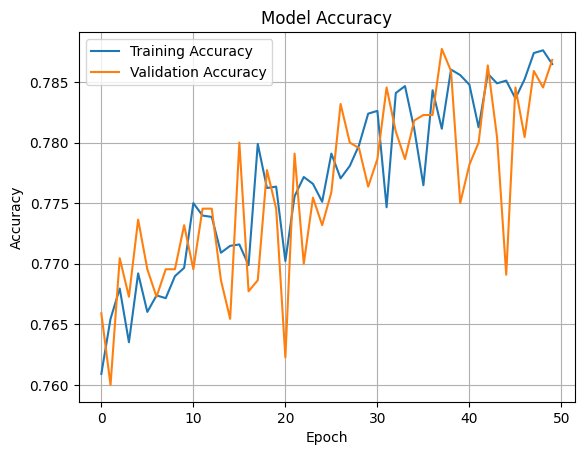

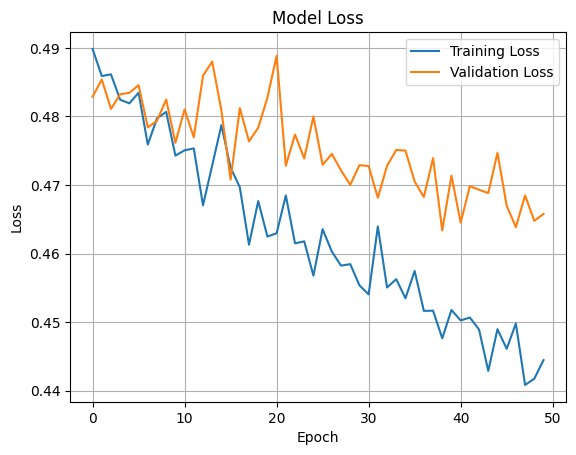

In [20]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


- Steep decline in model loss indicates model is learning and not memorizing data
- Steep incline in model accuracy is a positive sign and indicates increasing accuracy with every epoch

- ***Converting the predicted probabilites into class labels***

In [21]:
import numpy as np

# Predict class probabilities
y_pred_proba = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)  # if one-hot encoded


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, log_loss, matthews_corrcoef, cohen_kappa_score, 
    confusion_matrix, classification_report
)

# Basic metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')  # 'weighted' for multiclass
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
logloss = log_loss(y_test, y_pred_proba)  # use y_test (one-hot) and probs

# AUC for multiclass (macro-average)
try:
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
except:
    auc = None

# Print all
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC AUC       : {auc:.4f}" if auc else "ROC AUC: Not computable")
print(f"Log Loss      : {logloss:.4f}")
print(f"MCC           : {mcc:.4f}")
print(f"Cohen's Kappa : {kappa:.4f}")


Accuracy      : 0.7868
Precision     : 0.7937
Recall        : 0.7868
F1 Score      : 0.7815
ROC AUC       : 0.9581
Log Loss      : 0.4658
MCC           : 0.7376
Cohen's Kappa : 0.7334


***Confusion Matrix Score***

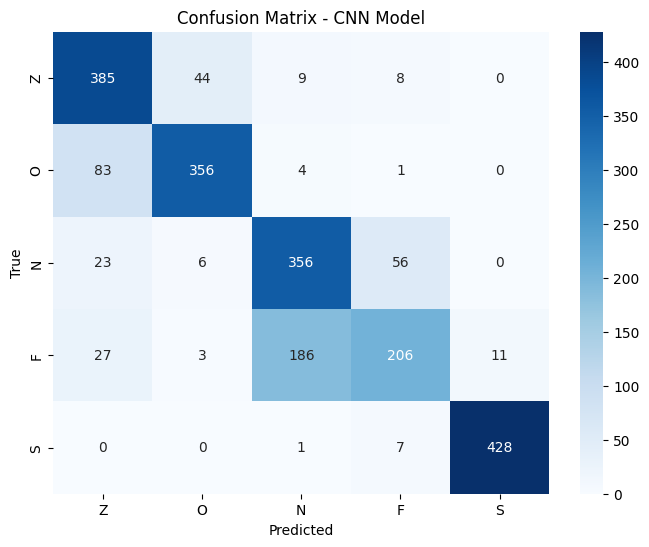


Classification Report:
              precision    recall  f1-score   support

           Z       0.74      0.86      0.80       446
           O       0.87      0.80      0.83       444
           N       0.64      0.81      0.71       441
           F       0.74      0.48      0.58       433
           S       0.97      0.98      0.98       436

    accuracy                           0.79      2200
   macro avg       0.79      0.79      0.78      2200
weighted avg       0.79      0.79      0.78      2200



In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
labels = ['Z', 'O', 'N', 'F', 'S']  

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN Model')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))


- ***Integration with LSTM***

In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8800, 13), (2200, 13), (8800, 5), (2200, 5))

In [25]:

from sklearn.model_selection import train_test_split

# Split 20% of X_train into validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


In [26]:
X_train.shape, X_test.shape, X_val.shape, y_val.shape

((7040, 13), (2200, 13), (1760, 13), (1760, 5))

In [27]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("New shape for CNN after reshaping:")
print("X_train:", X_train.shape)    
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

New shape for CNN after reshaping:
X_train: (7040, 13, 1)
X_val: (1760, 13, 1)
X_test: (2200, 13, 1)


### ***CNN + LSTM Model Architecture***

In [84]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, LSTM
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dense

input_layer = Input(shape=(13, 1))

# CNN Block
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

# LSTM Block
x = LSTM(64, return_sequences=True)(x)

# Attention Block
attn_output = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
attn_output = LayerNormalization()(attn_output + x)  # Add & Norm (residual connection)

# Final Layers
x = GlobalAveragePooling1D()(attn_output)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [85]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)


Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4678 - loss: 1.2167 - val_accuracy: 0.6381 - val_loss: 0.7833
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6078 - loss: 0.8470 - val_accuracy: 0.6597 - val_loss: 0.7186
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6690 - loss: 0.7282 - val_accuracy: 0.6614 - val_loss: 0.6814
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6644 - loss: 0.7168 - val_accuracy: 0.7284 - val_loss: 0.6211
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6954 - loss: 0.6637 - val_accuracy: 0.7131 - val_loss: 0.6392
Epoch 6/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7059 - loss: 0.6411 - val_accuracy: 0.7426 - val_loss: 0.5998
Epoch 7/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7241 - loss: 0.6087 - val_accuracy: 0.7375 - val_loss: 0.5938
Epoch 8/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7195 - loss: 0.6018 - val_accuracy: 0.

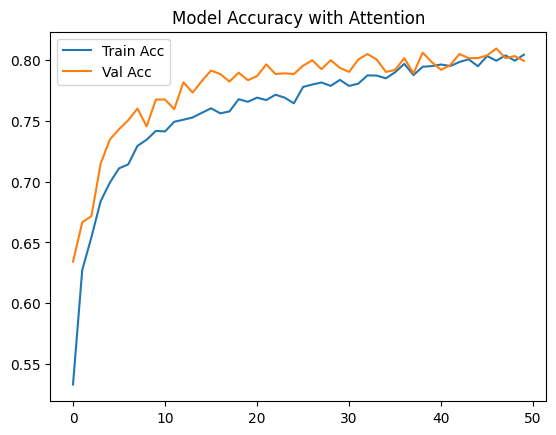

In [80]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy with Attention')
plt.legend()
plt.show()


In [86]:
#Converting predicted probabilities to class labels
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [87]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, matthews_corrcoef, cohen_kappa_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
logloss = log_loss(y_test, y_pred_proba)

try:
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
except:
    auc = None

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC AUC       : {auc:.4f}" if auc else "ROC AUC: Not computable")
print(f"Log Loss      : {logloss:.4f}")
print(f"MCC           : {mcc:.4f}")
print(f"Cohen's Kappa : {kappa:.4f}")


Accuracy      : 0.7823
Precision     : 0.7940
Recall        : 0.7823
F1 Score      : 0.7722
ROC AUC       : 0.9568
Log Loss      : 0.5029
MCC           : 0.7350
Cohen's Kappa : 0.7277


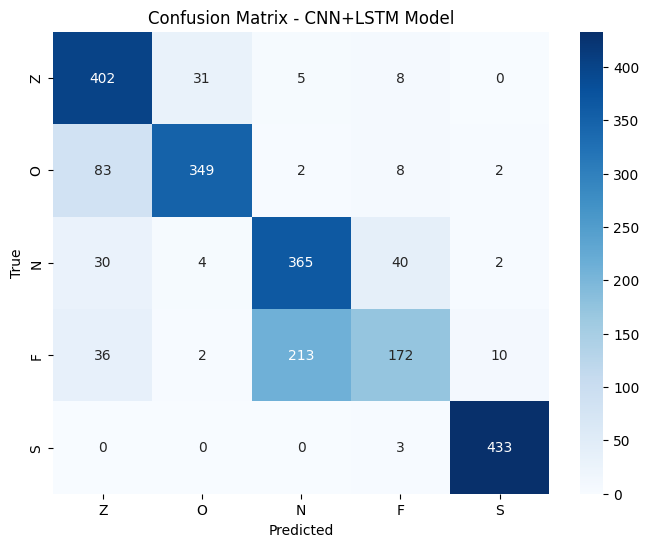

Classification Report:
              precision    recall  f1-score   support

           Z       0.73      0.90      0.81       446
           O       0.90      0.79      0.84       444
           N       0.62      0.83      0.71       441
           F       0.74      0.40      0.52       433
           S       0.97      0.99      0.98       436

    accuracy                           0.78      2200
   macro avg       0.79      0.78      0.77      2200
weighted avg       0.79      0.78      0.77      2200



In [88]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['Z', 'O', 'N', 'F', 'S']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN+LSTM Model')
plt.show()

# Detailed class-wise report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=labels))


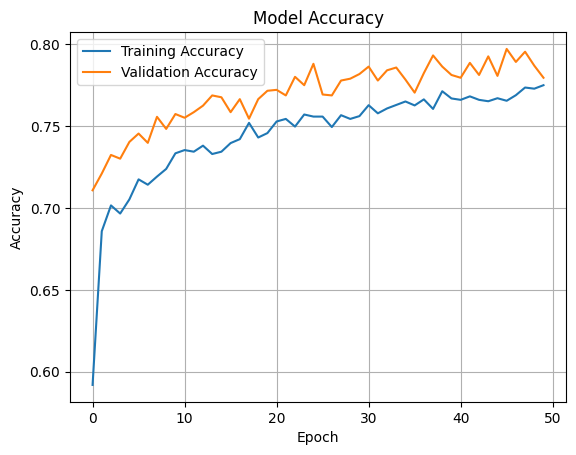

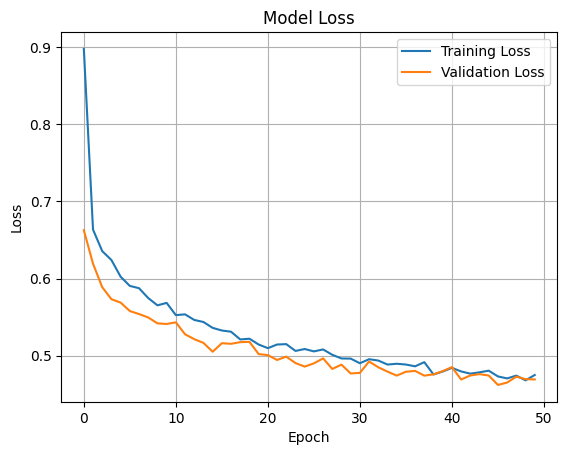

In [32]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### **Combining  CNN + LSTM with Random Forest Ensemble to improve Accuracy**

In [48]:
# If your CNN input looks like this (after reshape)
X_train.shape  # e.g., (7040, 13, 1)

# You need to flatten it back to 2D for Random Forest:
X_train_rf = X_train.reshape((X_train.shape[0], X_train.shape[1]))
X_test_rf = X_test.reshape((X_test.shape[0], X_test.shape[1]))

print(X_train.shape, X_train_rf.shape, X_test_rf.shape) 

(7040, 13, 1) (7040, 13) (2200, 13)


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Flatten data if needed (X_train: (8800, 13))
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_rf, y_train)

y_pred_rf = rf.predict(X_test_rf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.81      0.80      0.81       446
           1       0.91      0.81      0.86       444
           2       0.77      0.74      0.76       441
           3       0.77      0.65      0.71       433
           4       0.98      0.99      0.99       436

   micro avg       0.85      0.80      0.82      2200
   macro avg       0.85      0.80      0.82      2200
weighted avg       0.85      0.80      0.82      2200
 samples avg       0.80      0.80      0.80      2200



c:\Users\prani\OneDrive\Desktop\IEEE EMBS Internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- ***Setting CNN + LSTM Predictions as class probabilites***

In [52]:
cnn_preds_proba = model.predict(X_test)  # shape: (n_samples, num_classes)
cnn_preds_class = np.argmax(cnn_preds_proba, axis=1)


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [54]:
rf_preds_proba = rf.predict_proba(X_test_rf)  # shape: (n_samples, num_classes)


- ***Soft voting, i.e. taking avg og both CNN and RF probabilities and taking better score for each class***

In [70]:
# Reshaping rf_preds_proba in order to take average of both CNN and RF probabilities
import numpy as np
if isinstance(rf_preds_proba, list):
    rf_preds_proba = np.array([p[:, 1] for p in rf_preds_proba]).T  # shape: (2200, 5)

ensemble_proba = (cnn_preds_proba + rf_preds_proba) / 2
ensemble_preds = np.argmax(ensemble_proba, axis=1)
print("Ensemble Predictions:", ensemble_preds)


Ensemble Predictions: [1 2 3 ... 4 2 0]


### Bringing y_test and ensemble_preds to same shape

In [71]:
import numpy as np

# Fix y_test format if it's one-hot
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test  # Already in label format

# Now evaluation works
from sklearn.metrics import accuracy_score, classification_report

print("Ensemble Accuracy:", accuracy_score(y_test_labels, ensemble_preds))
print(classification_report(y_test_labels, ensemble_preds))


Ensemble Accuracy: 0.8290909090909091
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       446
           1       0.89      0.84      0.86       444
           2       0.74      0.80      0.77       441
           3       0.76      0.68      0.72       433
           4       0.98      0.98      0.98       436

    accuracy                           0.83      2200
   macro avg       0.83      0.83      0.83      2200
weighted avg       0.83      0.83      0.83      2200



In [77]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("Ensemble Accuracy:", accuracy_score(y_test_labels, ensemble_preds))
print("Ensemble F1 Score:", f1_score(y_test_labels, ensemble_preds, average="weighted"))
print(classification_report(y_test_labels, ensemble_preds, target_names=['Z', 'O', 'N', 'F', 'S']))


Ensemble Accuracy: 0.8290909090909091
Ensemble F1 Score: 0.8287028043720932
              precision    recall  f1-score   support

           Z       0.79      0.85      0.82       446
           O       0.89      0.84      0.86       444
           N       0.74      0.80      0.77       441
           F       0.76      0.68      0.72       433
           S       0.98      0.98      0.98       436

    accuracy                           0.83      2200
   macro avg       0.83      0.83      0.83      2200
weighted avg       0.83      0.83      0.83      2200



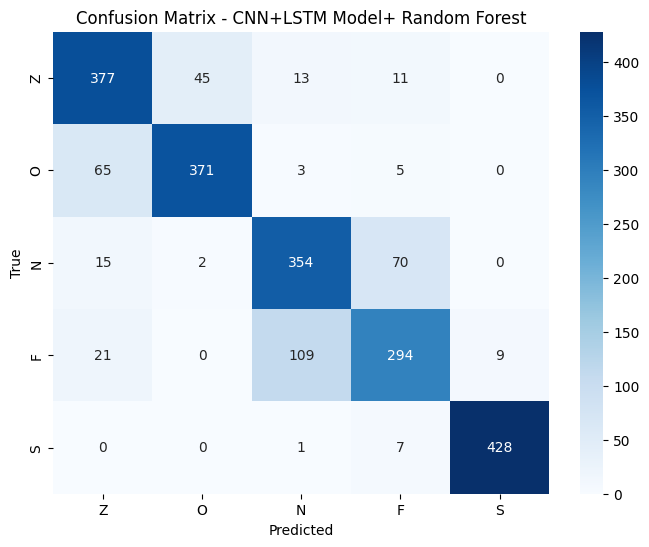

Classification Report:
              precision    recall  f1-score   support

           Z       0.77      0.82      0.80       446
           O       0.87      0.84      0.85       444
           N       0.68      0.76      0.72       441
           F       0.70      0.60      0.65       433
           S       0.98      0.98      0.98       436

    accuracy                           0.80      2200
   macro avg       0.80      0.80      0.80      2200
weighted avg       0.80      0.80      0.80      2200



In [76]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test_labels, ensemble_preds)
labels = ['Z', 'O', 'N', 'F', 'S']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN+LSTM Model+ Random Forest')
plt.show()

# Detailed class-wise report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=labels))